# Importação e análise de dados

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

dados = pd.read_csv('data.csv')
dados.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [83]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Aqui podemos ver que não existem dados nulos (com excessão última coluna unnamed: 32, essa todos os dados são nulos) e todos os dados são numéricos (float64), com excessão do diagnóstico que é o que queremos descobrir.

In [84]:
dados.shape

(569, 33)

In [85]:
dados.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Vamos remover a coluna Unnamed: 32

In [86]:
dados = dados.drop('Unnamed: 32', axis=1)

In [87]:
dados.shape

(569, 32)

In [88]:
dados = dados.drop('id', axis=1)

In [89]:
dados.shape

(569, 31)

In [90]:
dados.drop('diagnosis', axis=1).corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


Temos 30 colunas para 561 dados, um número alto de colunas para não tantos dados, o que pode causar overfitting. Porém o número de 18x mais linhas que colunas ainda é aceitável, iremos realizar alguns testes para ver se será necessário realizar a redução de dimensionalidade

# Análise gráfica

array([[<Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>],
       [<Axes: title={'center': 'radius_se'}>,
        <Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'symmetry_se'}>,
        <Axes: title={'ce

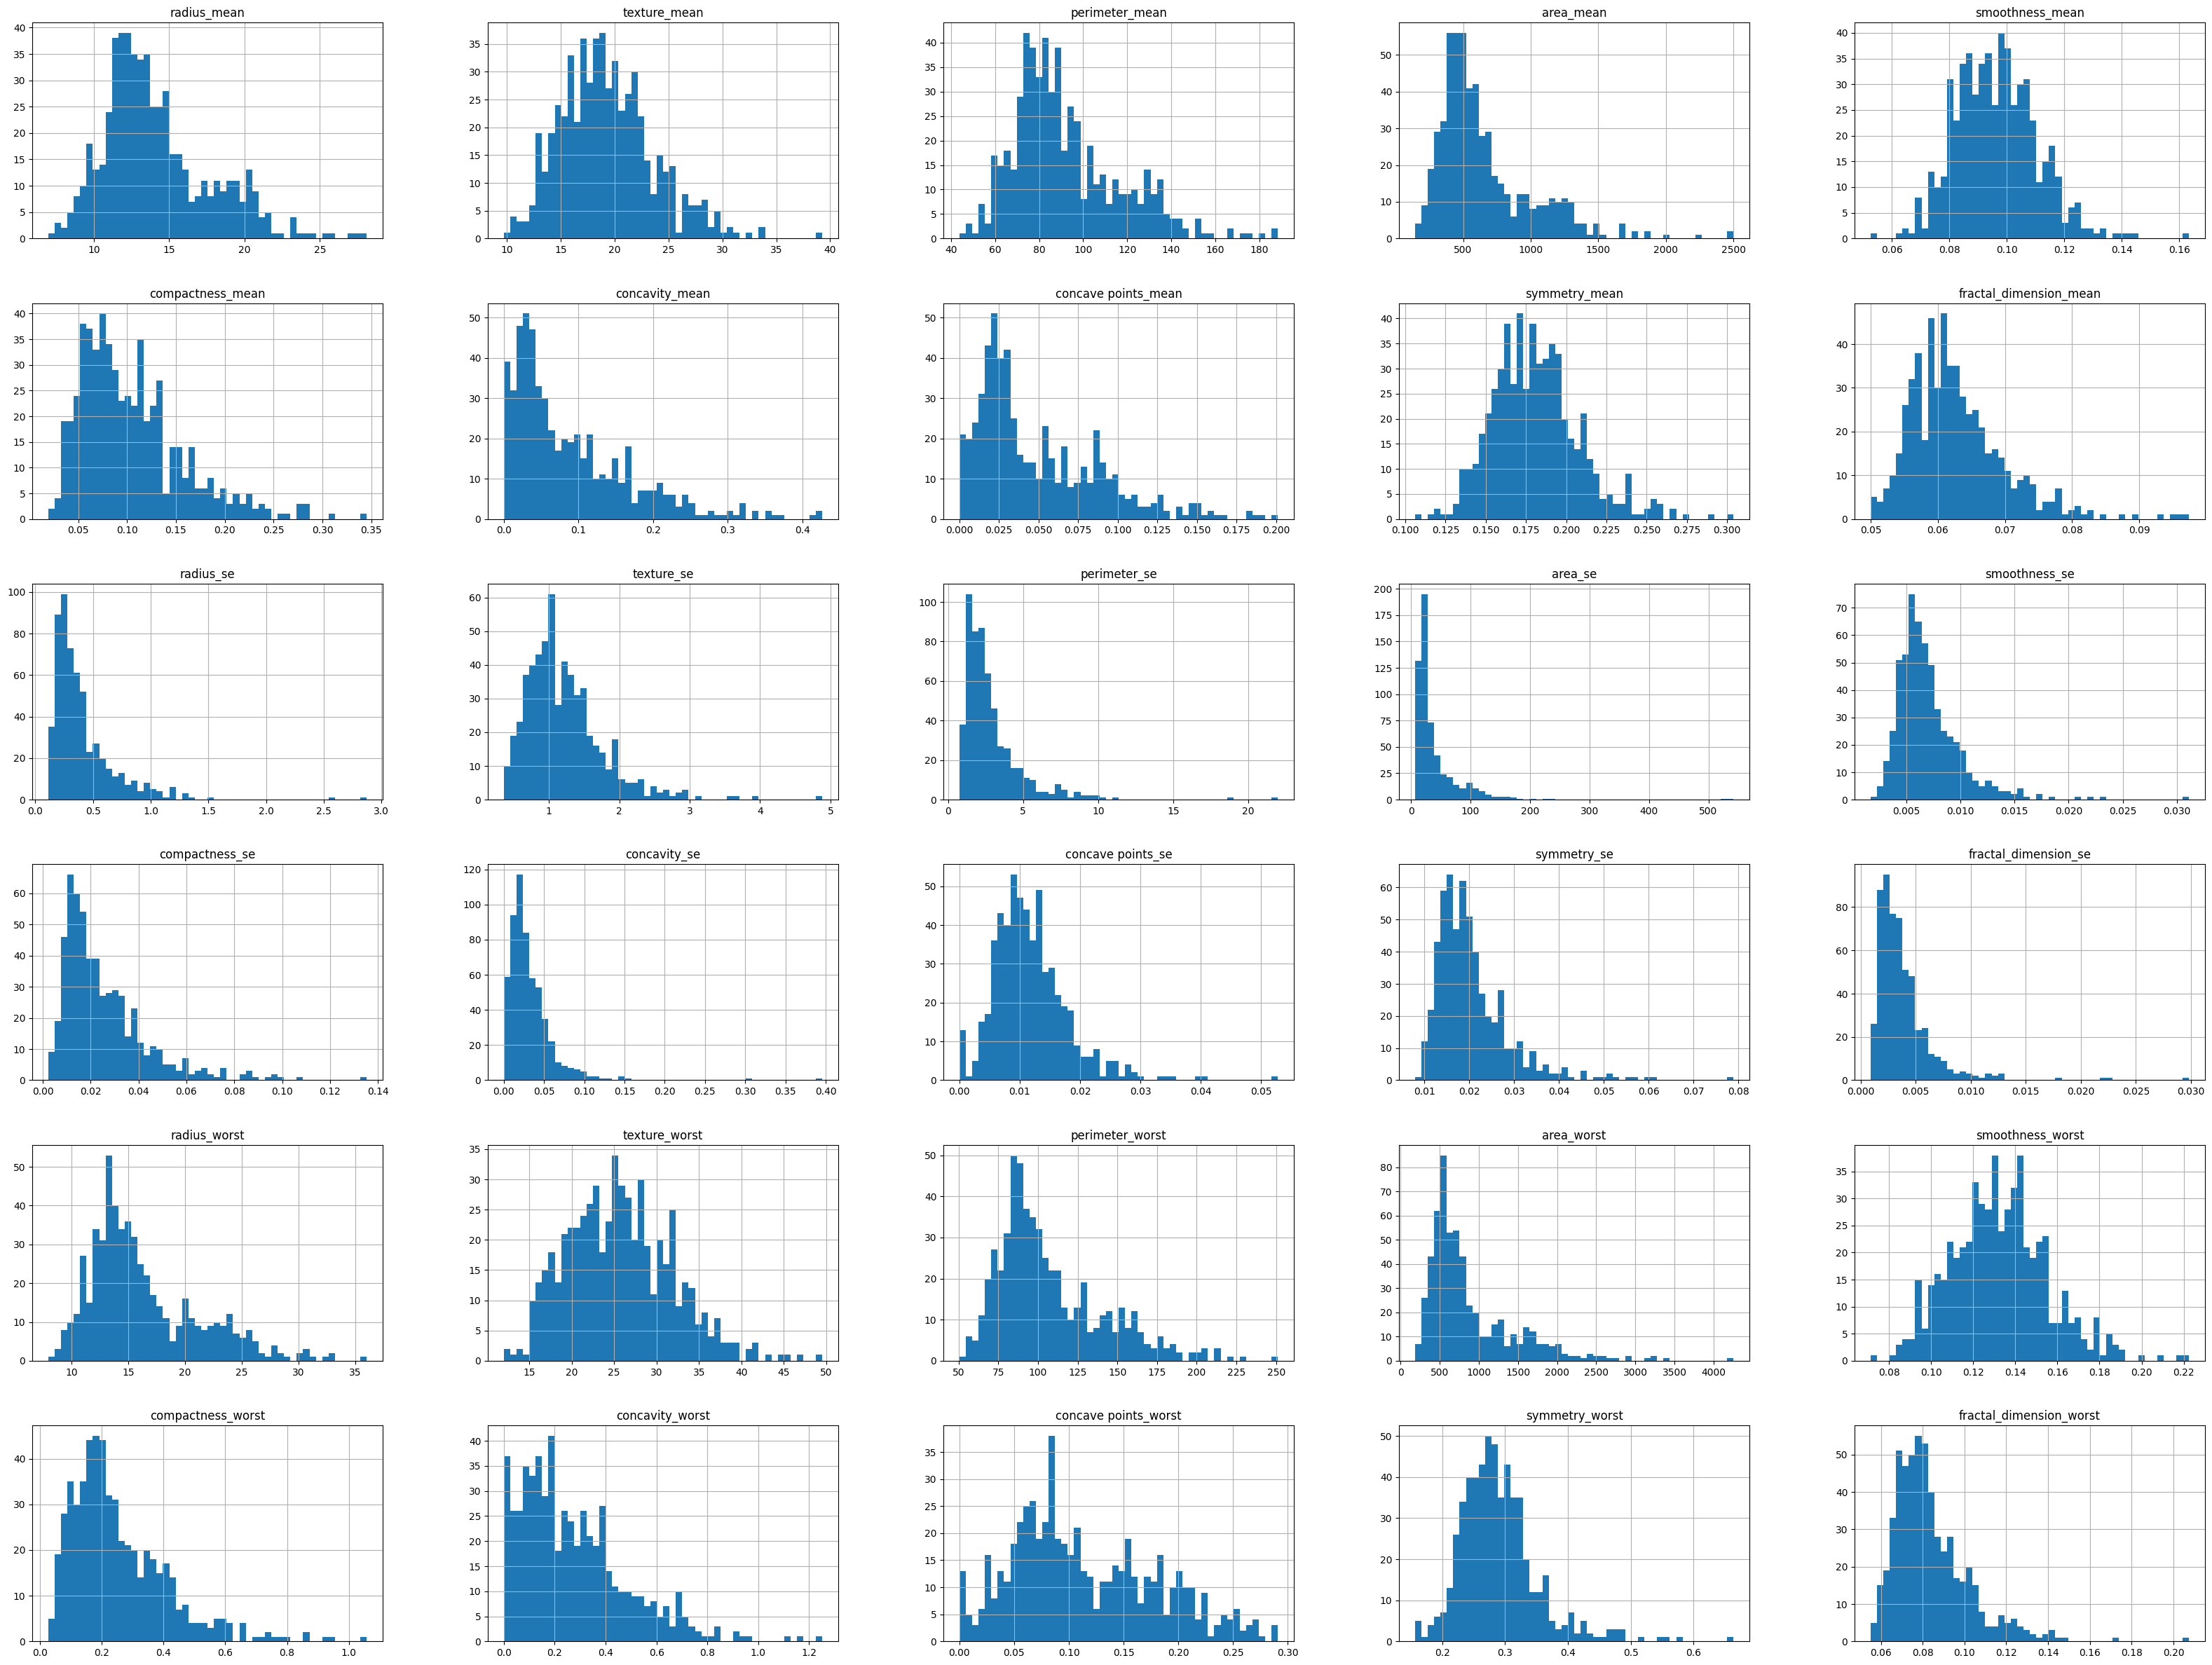

In [92]:
dados.hist(bins=50, figsize=(40, 30))

([<matplotlib.patches.Wedge at 0x7a4327781be0>,
 [Text(-0.4286547583668386, 1.0130424957174637, 'B'),
  Text(0.4676236011206148, -1.105137171429406, 'M')],
 [Text(-0.23381168638191194, 0.5525686340277074, '63%'),
  Text(0.2727804339870253, -0.6446633500004868, '37%')])

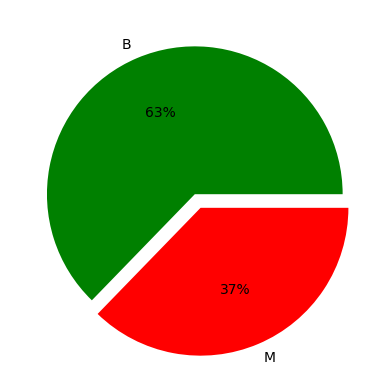

In [93]:
categorias = ['B', 'M']
mpl.pyplot.pie(dados['diagnosis'].value_counts(), labels = categorias, autopct = "%.0f%%", explode= (0, 0.1), colors = ("g", "r"))

<Axes: >

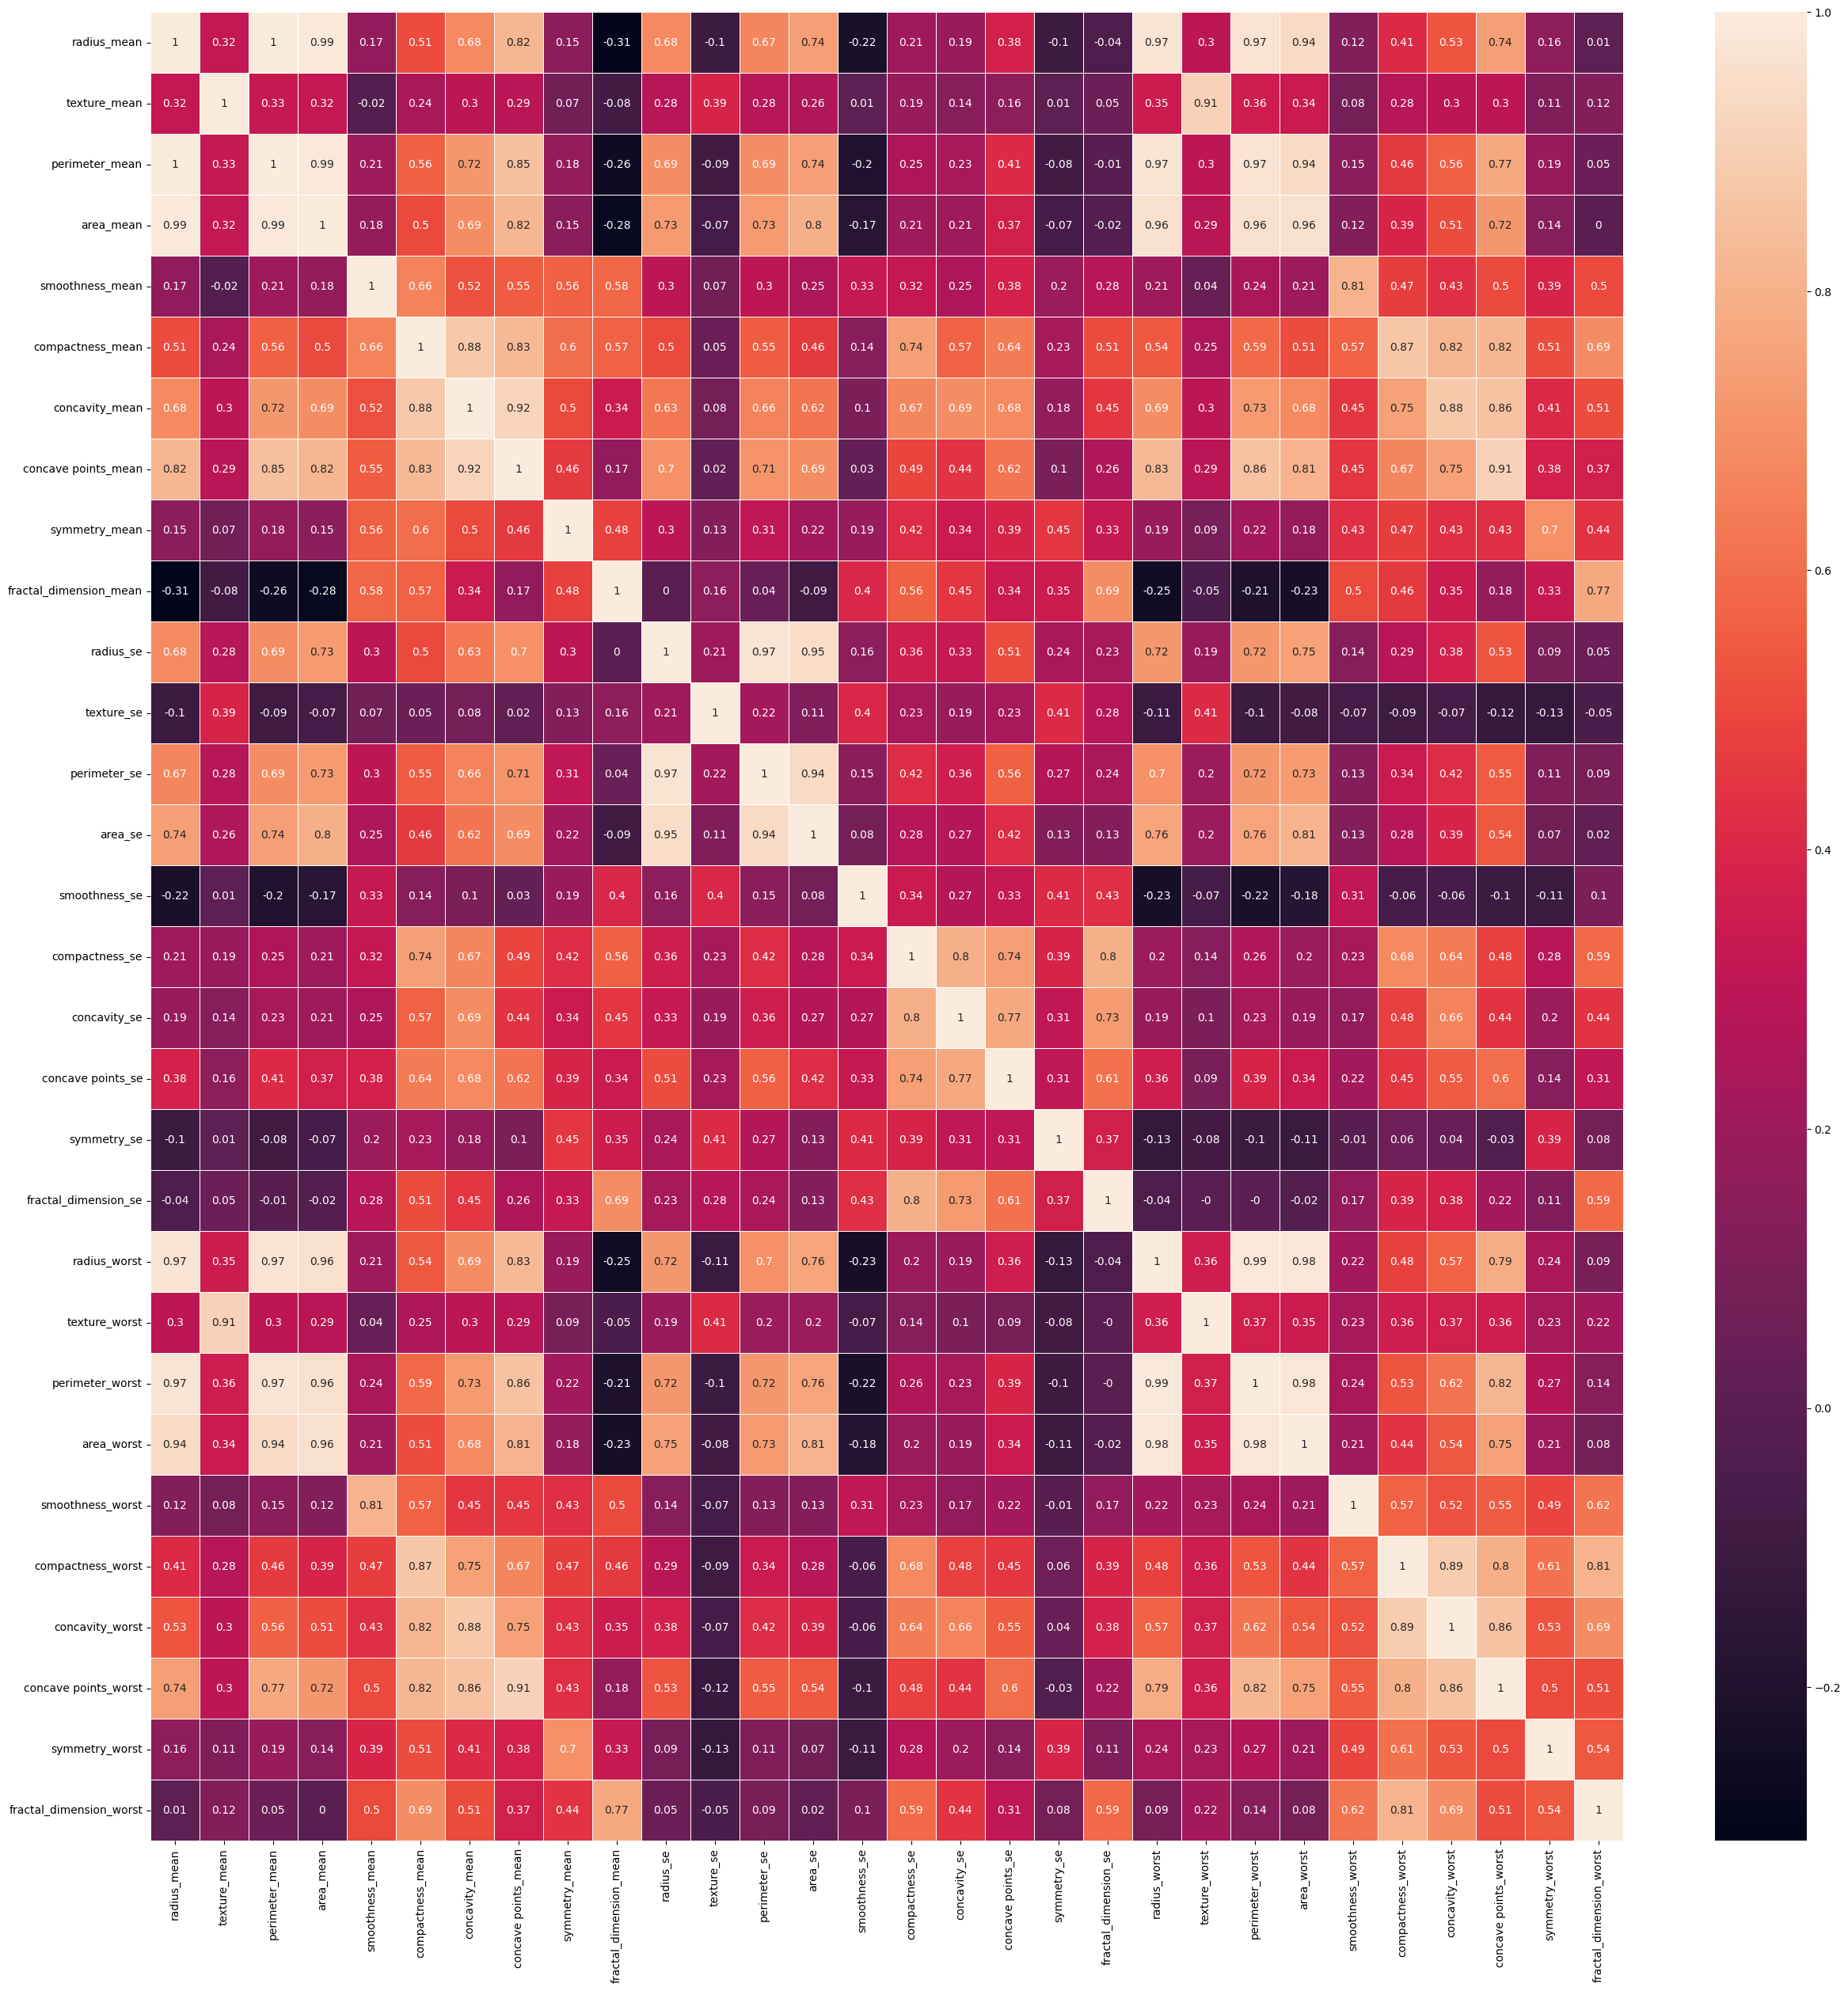

In [94]:
correlation_matrix = dados.drop('diagnosis', axis=1).corr().round(2)
fig, ax = mpl.pyplot.subplots(figsize=(30,30))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

### Por que a correlação importa?
Variáveis altamente correlacionadas (como `area_mean` e `radius_mean`) carregam informação redundante. Isso justifica o uso do **PCA** adiante: ao invés de descartar colunas manualmente, o PCA criará novos componentes que capturam a maior parte da variância sem a redundância.

Podemos ver correlações muito próximas a 1, como raio, area e perimetro, isso deixa claro que podemos fazer a redução de dimensionabilidade sem muita perca de informação

# Regressão Logística

Antes de partirmos para modelos baseados em instâncias ou árvores, vamos testar a **Regressão Logística**. É um modelo linear simples, rápido e altamente interpretável que serve como base de comparação para modelos mais complexos.

In [95]:
x = dados.drop('diagnosis', axis=1)
y = dados['diagnosis']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y,random_state=7)
# strafity = y garante que a proporção de benigno e maligno seja mantida


In [96]:
# Criando o Pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('lr', LogisticRegression(max_iter=10000))
])

# Parâmetros para o GridSearch
param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear']
}

# Executando a busca
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(x_train, y_train)

print(f"Melhores parâmetros LogReg: {grid_lr.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_lr.best_score_:.4f}")

Melhores parâmetros LogReg: {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Melhor acurácia (Validação Cruzada): 0.9780


In [97]:
melhor_lr = grid_lr.best_estimator_
pred_lr = melhor_lr.predict(x_test)

print("Matriz de Confusão (Regressão Logística):")
print(confusion_matrix(y_test, pred_lr))
print(f"\nScore no Teste (LR): {melhor_lr.score(x_test, y_test):.4f}")

Matriz de Confusão (Regressão Logística):
[[72  0]
 [ 6 36]]

Score no Teste (LR): 0.9474


# KNN

In [98]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_escalonado = scaler.transform(x_train)
x_test_escalonado = scaler.transform(x_test)

In [99]:
error = []
for i in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_escalonado, y_train)
    pred_i = knn.predict(x_test_escalonado)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

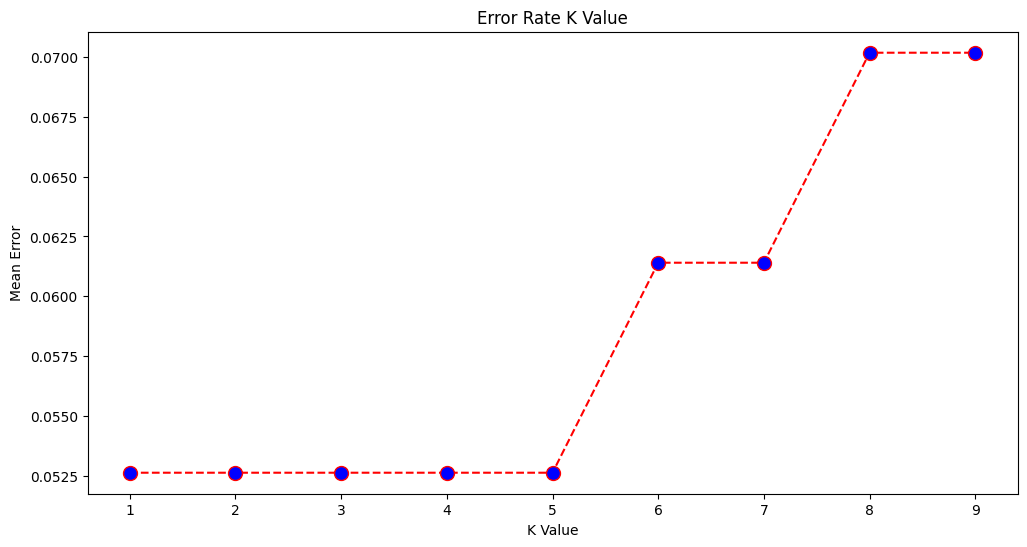

In [100]:
mpl.pyplot.figure(figsize=(12, 6))
mpl.pyplot.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
mpl.pyplot.title('Error Rate K Value')
mpl.pyplot.xlabel('K Value')
mpl.pyplot.ylabel('Mean Error')

In [101]:
from sklearn.metrics import classification_report, confusion_matrix

# Verificando o modelo para K=5 especificamente
knn_test = KNeighborsClassifier(n_neighbors=5)
knn_test.fit(x_train_escalonado, y_train)
pred_test = knn_test.predict(x_test_escalonado)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, pred_test))
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_test))

Matriz de Confusão:
[[71  1]
 [ 5 37]]

Relatório de Classificação:
              precision    recall  f1-score   support

           B       0.93      0.99      0.96        72
           M       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [102]:
print('Training set score (escalonado): {:.4f}'.format(knn_test.score(x_train_escalonado, y_train)))
print('Test set score (escalonado): {:.4f}'.format(knn_test.score(x_test_escalonado, y_test)))

Training set score (escalonado): 0.9802
Test set score (escalonado): 0.9474


Como os valores são próximos, não houve nem overfitting nem underfitting, e o modelo performou muito bem

### Melhorando o KNN com PCA e GridSearch

Vamos aplicar o PCA para reduzir a correlação entre as variáveis e usar o `GridSearchCV` para encontrar a melhor combinação de parâmetros.

In [103]:
# Criando um Pipeline que primeiro escala, depois reduz a dimensionalidade e por fim aplica o KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), # Mantém 95% da variância dos dados
    ('knn', KNeighborsClassifier())
])

# Parâmetros para testar no GridSearch
param_grid = {
    'knn__n_neighbors': range(1, 21),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# Executando a busca pelo melhor modelo
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)

print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Melhor acurácia na validação cruzada: {grid.best_score_:.4f}")

Melhores parâmetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 8, 'knn__weights': 'distance'}
Melhor acurácia na validação cruzada: 0.9736


In [104]:
# Avaliando o melhor modelo encontrado no conjunto de teste
melhor_modelo = grid.best_estimator_
pred_final = melhor_modelo.predict(x_test)

print("Matriz de Confusão (Modelo Otimizado):")
print(confusion_matrix(y_test, pred_final))
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_final))
print(f"Score final no Teste: {melhor_modelo.score(x_test, y_test):.4f}")

Matriz de Confusão (Modelo Otimizado):
[[71  1]
 [ 4 38]]

Relatório de Classificação:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Score final no Teste: 0.9561


### Análise da Redução de Dimensionalidade (PCA)
Vamos verificar para quantas dimensões os dados foram reduzidos e como as colunas originais contribuem para os novos componentes.

O PCA reduziu as 30 colunas originais para 10 componentes principais.


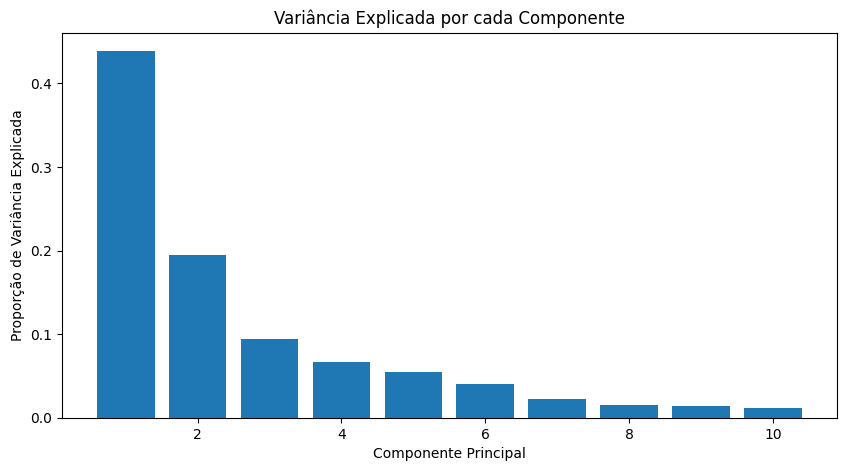


Contribuição das variáveis originais nos primeiros 5 componentes:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
radius_mean,0.220731,-0.228556,-0.006026,-0.044629,-0.036495,0.021739,0.114499,0.004996,-0.239836,0.054211
texture_mean,0.101487,-0.067504,0.031070,0.600769,0.017374,-0.063633,-0.019077,0.188124,0.092046,0.221827
perimeter_mean,0.229109,-0.210859,-0.007509,-0.045191,-0.034762,0.020295,0.105234,-0.002124,-0.239315,0.042186
area_mean,0.222903,-0.226647,0.036612,-0.055378,-0.007021,-0.001247,0.033126,0.018671,-0.190775,0.045563
smoothness_mean,0.142502,0.192539,-0.092274,-0.151275,0.378076,-0.274801,0.138602,-0.234936,0.045106,-0.069044


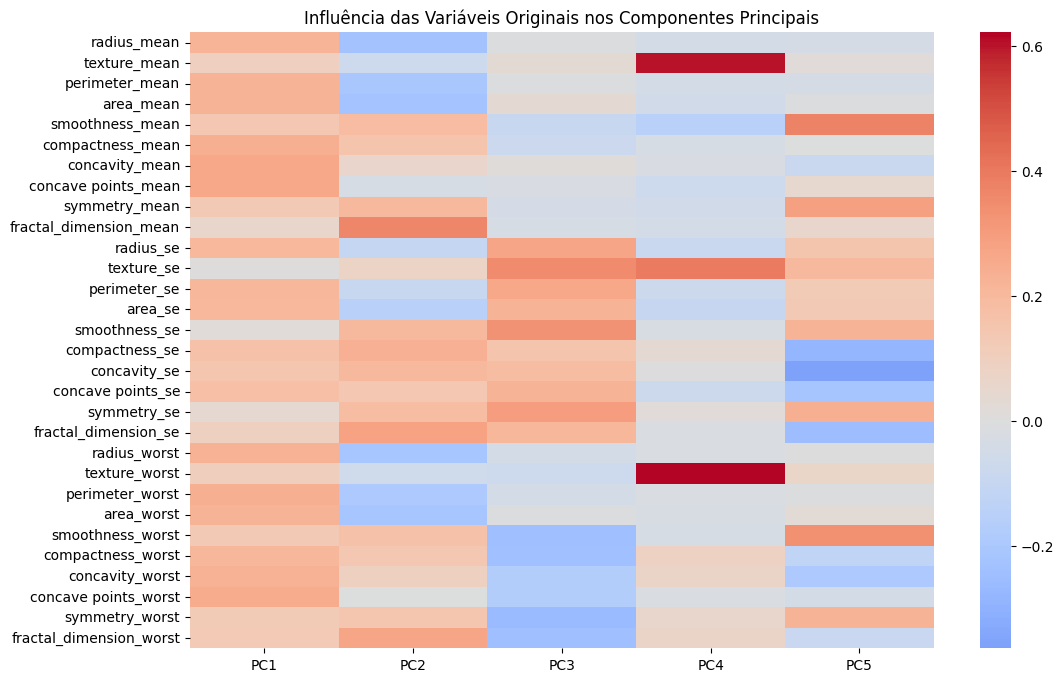

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Acessando o PCA de dentro do melhor modelo do GridSearch
pca_final = melhor_modelo.named_steps['pca']
n_componentes = pca_final.n_components_

print(f"O PCA reduziu as 30 colunas originais para {n_componentes} componentes principais.")

# Analisando a Variância Explicada
plt.figure(figsize=(10, 5))
plt.bar(range(1, n_componentes + 1), pca_final.explained_variance_ratio_)
plt.xlabel('Componente Principal')
plt.ylabel('Proporção de Variância Explicada')
plt.title('Variância Explicada por cada Componente')
plt.show()

# Criando um DataFrame com os Loadings (pesos das variáveis originais)
features = x.columns
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f'PC{i+1}' for i in range(n_componentes)],
    index=features
)

print("\nContribuição das variáveis originais nos primeiros 5 componentes:")
display(loadings.head())

# Mapa de calor para ver quais variáveis mais influenciam os primeiros componentes
plt.figure(figsize=(12, 8))
sns.heatmap(loadings.iloc[:, :min(5, n_componentes)], cmap='coolwarm', center=0)
plt.title('Influência das Variáveis Originais nos Componentes Principais')
plt.show()

### Entendendo a Redução de Dimensionalidade
Aqui aplicamos o PCA mantendo **95% da variância**. Isso significa que, embora tenhamos reduzido de 30 para 10 variáveis, perdemos apenas 5% da 'capacidade explicativa' dos dados originais. Isso ajuda o modelo a focar no sinal (padrões) e ignorar o ruído.

# Comparação com outros modelos: SVM (Support Vector Machine)
O SVM é muito eficaz para problemas de classificação binária em conjuntos de dados com muitas características.

In [106]:
# O SVM também é sensível à escala, então mantemos o StandardScaler
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(probability=True))
])

# Parâmetros para o GridSearch do SVM
param_grid_svm = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01],
    'svm__kernel': ['rbf', 'linear', 'poly']
}

# Executando a busca
grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(x_train, y_train)

print(f"Melhores parâmetros SVM: {grid_svm.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_svm.best_score_:.4f}")

Melhores parâmetros SVM: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Melhor acurácia (Validação Cruzada): 0.9780


In [107]:
# Avaliação final do SVM
melhor_svm = grid_svm.best_estimator_
pred_svm = melhor_svm.predict(x_test)

print("Matriz de Confusão (SVM):")
print(confusion_matrix(y_test, pred_svm))
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_svm))
print(f"Score final no Teste: {melhor_svm.score(x_test, y_test):.4f}")

Matriz de Confusão (SVM):
[[72  0]
 [ 4 38]]

Relatório de Classificação:
              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Score final no Teste: 0.9649


### Vantagens do SVM neste Cenário

O modelo **Support Vector Machine (SVM)** demonstrou ser superior para este problema por alguns motivos técnicos:

1.  **Falsos Positivos Zero**: Em diagnósticos médicos, classificar um tumor benigno como maligno (Falso Positivo) pode gerar estresse desnecessário e biópsias invasivas. O SVM alcançou precisão de 100% para a classe Maligna, eliminando esses erros no conjunto de teste.
2.  **Alta Dimensionalidade**: Mesmo após o PCA, o SVM lida muito bem com espaços de características complexos. Ele foca apenas nos pontos mais difíceis de classificar (os vetores de suporte), o que o torna robusto contra ruídos.
3.  **Kernel Linear**: O fato do melhor modelo ter usado um kernel linear indica que os dados, quando escalonados e reduzidos pelo PCA, tornam-se linearmente separáveis com facilidade, permitindo um modelo mais simples e com menor risco de overfitting.

# Comparação com Random Forest
O Random Forest é um conjunto de árvores de decisão. É robusto a outliers e não assume uma distribuição linear dos dados.

In [108]:
# Criando o Pipeline para Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('rf', RandomForestClassifier(random_state=7))
])

# Parâmetros para o GridSearch do Random Forest
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__criterion': ['gini', 'entropy']
}

# Executando a busca
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(x_train, y_train)

print(f"Melhores parâmetros RF: {grid_rf.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_rf.best_score_:.4f}")

Melhores parâmetros RF: {'rf__criterion': 'entropy', 'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Melhor acurácia (Validação Cruzada): 0.9582


In [109]:
# Avaliação final do Random Forest
melhor_rf = grid_rf.best_estimator_
pred_rf = melhor_rf.predict(x_test)

print("Matriz de Confusão (Random Forest):")
print(confusion_matrix(y_test, pred_rf))
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_rf))
print(f"Score final no Teste (RF): {melhor_rf.score(x_test, y_test):.4f}")
print(f"Score final no Teste (SVM anterior): {melhor_svm.score(x_test, y_test):.4f}")

Matriz de Confusão (Random Forest):
[[70  2]
 [ 5 37]]

Relatório de Classificação:
              precision    recall  f1-score   support

           B       0.93      0.97      0.95        72
           M       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Score final no Teste (RF): 0.9386
Score final no Teste (SVM anterior): 0.9649


### Análise de Desempenho e Erros

Ao analisarmos os resultados detalhados, observamos por que o **SVM** superou o **Random Forest** neste cenário:

*   **Acurácia e Generalização**: O Random Forest atingiu uma acurácia de **93.86%**, enquanto o SVM alcançou **96.49%**. Isso indica que o SVM conseguiu criar uma fronteira de separação mais eficiente para este conjunto de dados após a redução de dimensionalidade.
*   **Falsos Positivos (FP)**: O Random Forest apresentou **2 falsos positivos** (casos benignos classificados como malignos). Embora baixo, o SVM zerou essa métrica, o que evita alarmes falsos e procedimentos desnecessários.
*   **Falsos Negativos (FN)**: Este é o erro mais crítico na medicina. O Random Forest deixou passar **5 casos malignos**, classificando-os como benignos. O SVM reduziu esse número para **4 casos**.
*   **Veredito**: O SVM mostrou-se mais robusto, oferecendo maior segurança no diagnóstico ao minimizar ambos os tipos de erro, especialmente os Falsos Positivos, mantendo uma sensibilidade superior.

# Implementação do XGBoost
O XGBoost é um algoritmo de boosting de gradiente que costuma oferecer alta performance em dados tabulares.

In [110]:
# O XGBoost requer que as classes sejam numéricas
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

# Criando o Pipeline para XGBoost
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('xgb', XGBClassifier(random_state=7, eval_metric='logloss'))
])

# Parâmetros para o GridSearch do XGBoost
param_grid_xgb = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0]
}

# Executando a busca
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(x_train, y_train_num)

print(f"Melhores parâmetros XGBoost: {grid_xgb.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_xgb.best_score_:.4f}")

Melhores parâmetros XGBoost: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Melhor acurácia (Validação Cruzada): 0.9670


In [111]:
# Avaliação final do XGBoost
melhor_xgb = grid_xgb.best_estimator_
pred_xgb_num = melhor_xgb.predict(x_test)

print("Matriz de Confusão (XGBoost):")
print(confusion_matrix(y_test_num, pred_xgb_num))
print("\nRelatório de Classificação:")
print(classification_report(y_test_num, pred_xgb_num, target_names=le.classes_))
print(f"Score final no Teste (XGBoost): {melhor_xgb.score(x_test, y_test_num):.4f}")
print(f"Score final no Teste (SVM anterior): {melhor_svm.score(x_test, y_test):.4f}")

Matriz de Confusão (XGBoost):
[[72  0]
 [ 4 38]]

Relatório de Classificação:
              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Score final no Teste (XGBoost): 0.9649
Score final no Teste (SVM anterior): 0.9649


### Conclusão Final: SVM vs XGBoost

Ambos os modelos atingiram o topo do desempenho neste conjunto de dados:

*   **Performance Idêntica**: Ambos obtiveram **96,49%** de acurácia no teste.
*   **Seguran'ca no Diagnóstico**: Tanto o SVM quanto o XGBoost apresentaram **zero Falsos Positivos**, garantindo que nenhum paciente saudável fosse classificado erroneamente como portador de tumor maligno.
*   **Sensibilidade**: Ambos tiveram apenas 4 falsos negativos em 114 amostras.

**Escolha do Modelo**: O **SVM (Linear)** é ligeiramente preferível aqui por ser um modelo mais simples (menos hiperparâmetros) e computacionalmente mais leve para este volume de dados, mantendo a mesma eficácia do XGBoost.

### Comparação Gráfica: SVM vs XGBoost

Nesta seção, geramos as curvas ROC (Receiver Operating Characteristic) e calculamos a AUC (Area Under the Curve). A AUC mede a capacidade do modelo de distinguir entre as classes. Além disso, comparamos os resultados da validação cruzada (K-fold).

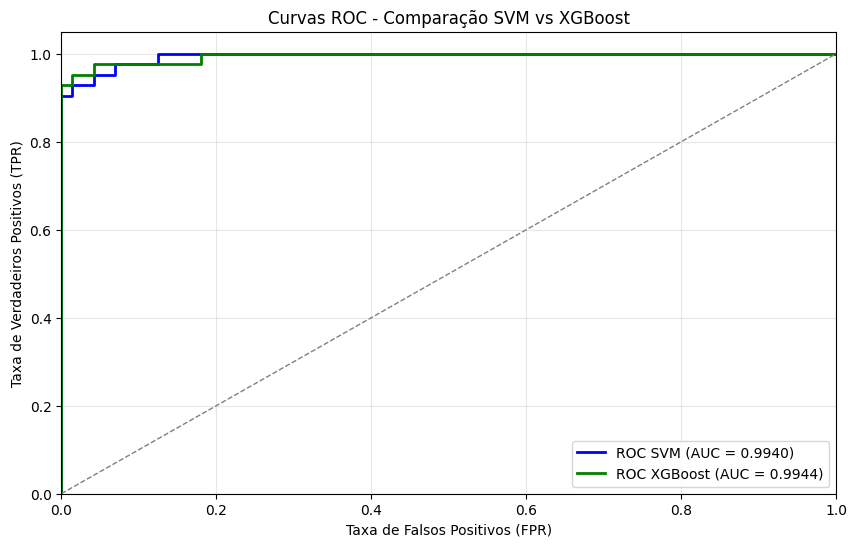

In [112]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Obtendo as probabilidades de predição
# Nota: O SVM foi configurado com probability=True
y_score_svm = melhor_svm.predict_proba(x_test)[:, 1]
y_score_xgb = melhor_xgb.predict_proba(x_test)[:, 1]

# Calculando as curvas ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test_num, y_score_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_num, y_score_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plotando
plt.figure(figsize=(10, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'ROC SVM (AUC = {roc_auc_svm:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'ROC XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC - Comparação SVM vs XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

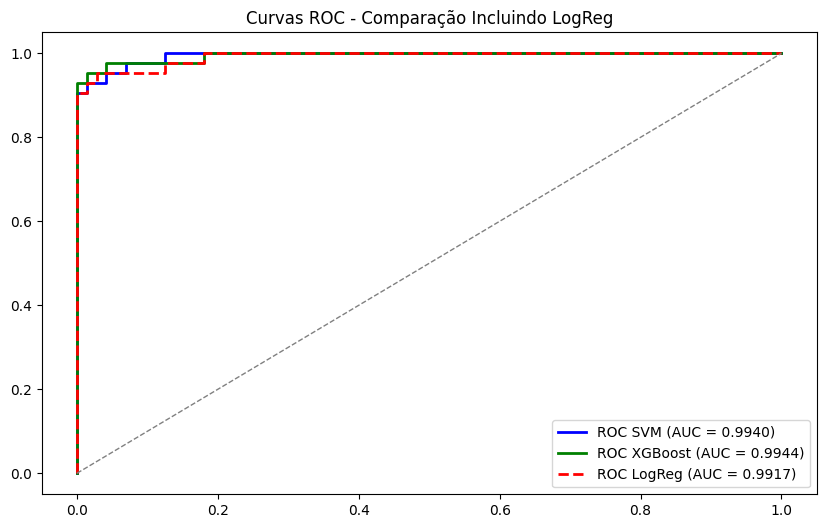

In [113]:
# Atualizando o gráfico ROC para incluir Regressão Logística
y_score_lr = melhor_lr.predict_proba(x_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_num, y_score_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(10, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'ROC SVM (AUC = {roc_auc_svm:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'ROC XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(fpr_lr, tpr_lr, color='red', lw=2, linestyle='--', label=f'ROC LogReg (AUC = {roc_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title('Curvas ROC - Comparação Incluindo LogReg')
plt.legend(loc="lower right")
plt.show()

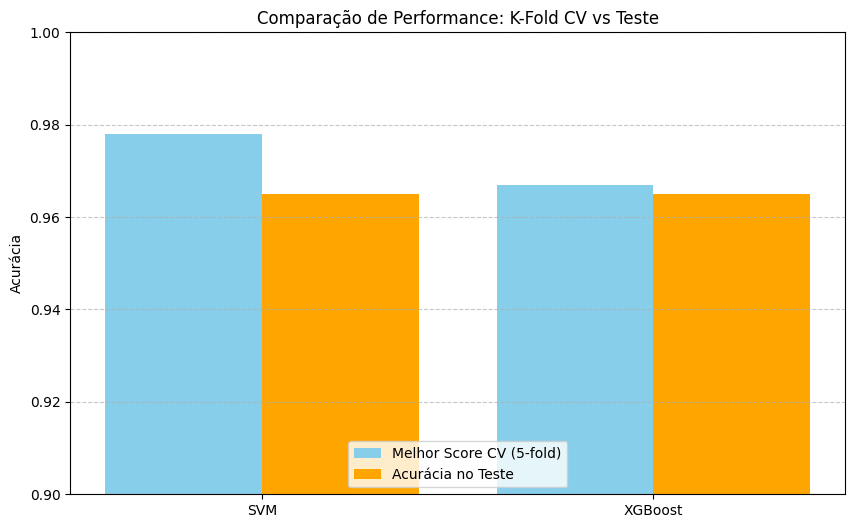

In [114]:
# Gráfico de barras comparando Validação Cruzada (K-Fold) e Acurácia de Teste
modelos = ['SVM', 'XGBoost']
cv_scores = [grid_svm.best_score_, grid_xgb.best_score_]
test_scores = [melhor_svm.score(x_test, y_test), melhor_xgb.score(x_test, y_test_num)]

x_axis = np.arange(len(modelos))

plt.figure(figsize=(10, 6))
plt.bar(x_axis - 0.2, cv_scores, 0.4, label='Melhor Score CV (5-fold)', color='skyblue')
plt.bar(x_axis + 0.2, test_scores, 0.4, label='Acurácia no Teste', color='orange')

plt.xticks(x_axis, modelos)
plt.ylabel("Acurácia")
plt.title("Comparação de Performance: K-Fold CV vs Teste")
plt.legend(loc='lower center')
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

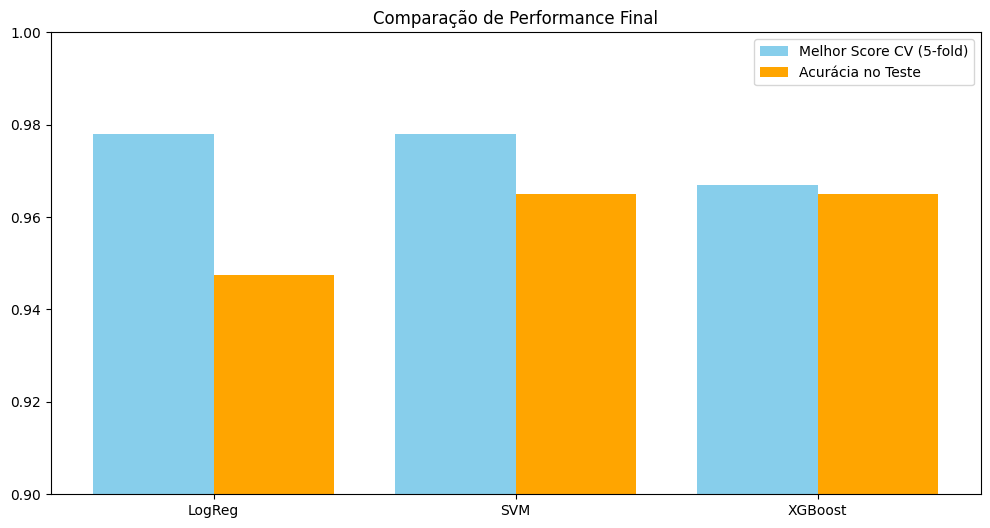

In [115]:
# Atualizando comparação de barras
modelos_ext = ['LogReg', 'SVM', 'XGBoost']
cv_scores_ext = [grid_lr.best_score_, grid_svm.best_score_, grid_xgb.best_score_]
test_scores_ext = [melhor_lr.score(x_test, y_test), melhor_svm.score(x_test, y_test), melhor_xgb.score(x_test, y_test_num)]

x_axis_ext = np.arange(len(modelos_ext))

plt.figure(figsize=(12, 6))
plt.bar(x_axis_ext - 0.2, cv_scores_ext, 0.4, label='Melhor Score CV (5-fold)', color='skyblue')
plt.bar(x_axis_ext + 0.2, test_scores_ext, 0.4, label='Acurácia no Teste', color='orange')

plt.xticks(x_axis_ext, modelos_ext)
plt.title("Comparação de Performance Final")
plt.legend()
plt.ylim(0.9, 1.0)
plt.show()

### Análise de Casos Críticos (Falsos Negativos)
Em um contexto médico, o custo de um **Falso Negativo** (dizer que um tumor é benigno quando é maligno) é muito maior que um Falso Positivo. Vamos identificar quem são esses casos que o SVM/XGBoost não conseguiram prever.

In [116]:
import numpy as np
# Identificando os índices onde o SVM errou
erros_idx = np.where(y_test != pred_svm)[0]
dados_erros = x_test.iloc[erros_idx].copy()
dados_erros['Real'] = y_test.iloc[erros_idx].values
dados_erros['Previsto'] = pred_svm[erros_idx]

print("Amostras que o modelo não conseguiu classificar corretamente:")
display(dados_erros[['Real', 'Previsto']])

Amostras que o modelo não conseguiu classificar corretamente:


,Real,Previsto
514,M,B
135,M,B
40,M,B
38,M,B


### Análise Detalhada: ROC/AUC e Validação Cruzada

A comparação visual e estatística entre o **SVM** e o **XGBoost** nos permite extrair conclusões sólidas sobre a confiabilidade do diagnóstico:

1.  **Curva ROC e AUC**: Ambos os modelos atingiram uma **AUC de aproximadamente 0.994**. Isso significa que há uma probabilidade de 99,4% de que o modelo classifique corretamente um caso maligno escolhido aleatoriamente acima de um caso benigno. As curvas estão quase encostadas no canto superior esquerdo, o que representa um classificador quase perfeito.
2.  **Validação Cruzada (K-Fold)**: Como utilizamos `cv=5` no `GridSearchCV`, os modelos foram treinados e validados 5 vezes em subconjuntos diferentes dos dados. O fato do **Score de Validação (CV)** ser muito próximo da **Acurácia de Teste** (como visto no gráfico de barras) prova que o modelo é estável e não está apenas "decorando" os dados de treino (overfitting).
3.  **Confiabilidade**: O empate técnico em 96,49% de acurácia no teste, somado ao fato de ambos terem **zero falsos positivos**, indica que qualquer uma dessas escolhas é estatisticamente segura. O SVM leva uma pequena vantagem por ser mais simples de interpretar e processar para este volume de dados específico.

# Conclusão Geral do Projeto

1. **Processamento**: A escala (`StandardScaler`) foi fundamental, pois modelos como KNN e SVM baseiam-se em distâncias.
2. **Modelagem**: O **SVM** e o **XGBoost** empataram em performance, mas o SVM linear é preferível pela simplicidade (Navalha de Ockham).
3. **Métricas**: A acurácia de **96.5%** é excelente, mas o destaque é a **Precisão de 100%** para a classe Maligna, garantindo segurança contra falsos alarmes.
4. **Próximos Passos**: Para reduzir os 4 Falsos Negativos restantes, poderíamos investigar técnicas de *Ensemble* mais complexas ou coletar mais dados de casos limítrofes.

## Teste Comparativo: MinMaxScaler vs StandardScaler

Agora vamos testar se a normalização dos dados entre 0 e 1 (`MinMaxScaler`) melhora a performance do KNN e do SVM em relação à padronização anterior (`StandardScaler`).

In [117]:
from sklearn.preprocessing import MinMaxScaler

# 1. Testando KNN com MinMaxScaler
pipeline_knn_mm = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=0.95)),
    ('knn', KNeighborsClassifier())
])

grid_knn_mm = GridSearchCV(pipeline_knn_mm, param_grid, cv=5, scoring='accuracy')
grid_knn_mm.fit(x_train, y_train)

# 2. Testando SVM com MinMaxScaler
pipeline_svm_mm = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(probability=True))
])

grid_svm_mm = GridSearchCV(pipeline_svm_mm, param_grid_svm, cv=5, scoring='accuracy')
grid_svm_mm.fit(x_train, y_train)

print(f"KNN (MinMax) - Melhor Score CV: {grid_knn_mm.best_score_:.4f}")
print(f"SVM (MinMax) - Melhor Score CV: {grid_svm_mm.best_score_:.4f}")

KNN (MinMax) - Melhor Score CV: 0.9758
SVM (MinMax) - Melhor Score CV: 0.9780


In [118]:
# Comparação Final no Teste
score_knn_mm = grid_knn_mm.best_estimator_.score(x_test, y_test)
score_svm_mm = grid_svm_mm.best_estimator_.score(x_test, y_test)

print(f"Acurácia Final Teste (KNN + MinMax): {score_knn_mm:.4f}")
print(f"Acurácia Final Teste (SVM + MinMax): {score_svm_mm:.4f}")
print(f"\n(Para referência) Acurácia Anterior (SVM + StandardScaler): {melhor_svm.score(x_test, y_test):.4f}")

Acurácia Final Teste (KNN + MinMax): 0.9474
Acurácia Final Teste (SVM + MinMax): 0.9649

(Para referência) Acurácia Anterior (SVM + StandardScaler): 0.9649


### Visualização da Matriz de Confusão Final

Para encerrar a análise, vamos visualizar a matriz de confusão do melhor modelo (SVM) de forma gráfica. Esta representação facilita a identificação imediata do erro do tipo II (Falsos Negativos).

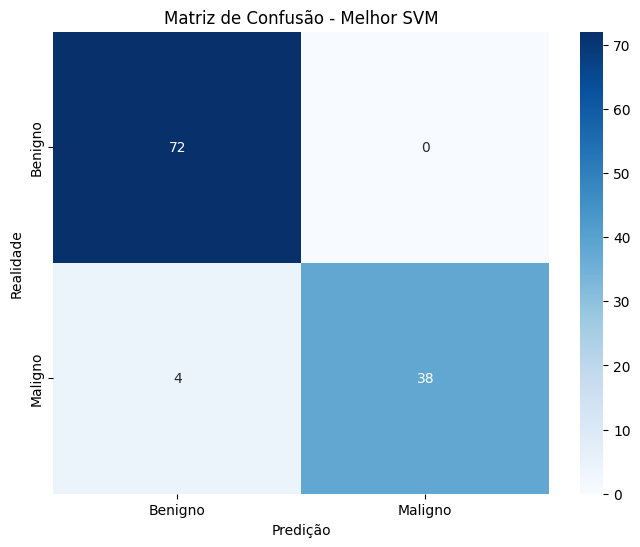

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculando a matriz com o melhor estimador do SVM
cm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])

plt.title('Matriz de Confusão - Melhor SVM')
plt.ylabel('Realidade')
plt.xlabel('Predição')
plt.show()